In [2]:
'''
Ejercicio 2: Análisis del Gimbal Lock en SymPy (Implementación)
'''
import sympy as sp
# Declaración de variables simbólicas
phi, theta, psi = sp.symbols('phi theta psi')

# Definición de matrices simbólicas y producto R_ZYZ
# Rotación en Z por phi
R_z_phi = sp.Matrix([
    [sp.cos(phi), -sp.sin(phi), 0],
    [sp.sin(phi),  sp.cos(phi), 0],
    [0,           0,            1]
])

# Rotación en Y por theta
R_y_theta = sp.Matrix([
    [ sp.cos(theta), 0, sp.sin(theta)],
    [ 0,             1, 0            ],
    [-sp.sin(theta), 0, sp.cos(theta)]
])

# Rotación en Z por psi
R_z_psi = sp.Matrix([
    [sp.cos(psi), -sp.sin(psi), 0],
    [sp.sin(psi),  sp.cos(psi), 0],
    [0,           0,            1]
])

# Multiplicación matricial simbólica Z-Y-Z
R_ZYZ = R_z_phi * R_y_theta * R_z_psi

print("2. Matriz R_ZYZ Simbólica General")
print()
sp.pprint(sp.simplify(R_ZYZ))
print("\n" + "="*50 + "\n")


# Sustitución de theta = 0 y simplificación

R_ZYZ_singular = sp.simplify(R_ZYZ.subs(theta, 0))

print("3. Matriz R_ZYZ evaluada en theta = 0")
print()
sp.pprint(R_ZYZ_singular)
print("\n" + "="*50 + "\n")

# Cálculo de derivadas parciales y demostración de dependencia lineal

# Derivada parcial respecto a phi, evaluada en theta = 0
dR_dphi = sp.simplify(sp.diff(R_ZYZ, phi).subs(theta, 0))

# Derivada parcial respecto a psi, evaluada en theta = 0
dR_dpsi = sp.simplify(sp.diff(R_ZYZ, psi).subs(theta, 0))

print("4. Derivadas Parciales en theta = 0")
print()
print("d(R_ZYZ)/d(phi) | theta=0:")
sp.pprint(dR_dphi)

print("\nd(R_ZYZ)/d(psi) | theta=0:")
sp.pprint(dR_dpsi)

# Verificación de igualdad
son_iguales = (dR_dphi == dR_dpsi)
print(f"\n¿Son idénticas las derivadas parciales?: {son_iguales}")

2. Matriz R_ZYZ Simbólica General

⎡-sin(φ)⋅sin(ψ) + cos(φ)⋅cos(ψ)⋅cos(θ)  -sin(φ)⋅cos(ψ) - sin(ψ)⋅cos(φ)⋅cos(θ)  ↪
⎢                                                                              ↪
⎢sin(φ)⋅cos(ψ)⋅cos(θ) + sin(ψ)⋅cos(φ)   -sin(φ)⋅sin(ψ)⋅cos(θ) + cos(φ)⋅cos(ψ)  ↪
⎢                                                                              ↪
⎣           -sin(θ)⋅cos(ψ)                          sin(ψ)⋅sin(θ)              ↪

↪  sin(θ)⋅cos(φ)⎤
↪               ⎥
↪  sin(φ)⋅sin(θ)⎥
↪               ⎥
↪     cos(θ)    ⎦


3. Matriz R_ZYZ evaluada en theta = 0

⎡cos(φ + ψ)  -sin(φ + ψ)  0⎤
⎢                          ⎥
⎢sin(φ + ψ)  cos(φ + ψ)   0⎥
⎢                          ⎥
⎣    0            0       1⎦


4. Derivadas Parciales en theta = 0

d(R_ZYZ)/d(phi) | theta=0:
⎡-sin(φ + ψ)  -cos(φ + ψ)  0⎤
⎢                           ⎥
⎢cos(φ + ψ)   -sin(φ + ψ)  0⎥
⎢                           ⎥
⎣     0            0       0⎦

d(R_ZYZ)/d(psi) | theta=0:
⎡-sin(φ + ψ)  -cos(φ + ψ)  0⎤
⎢        

--- Apartado 1 y 2: theta = 0.0001° ---
Matriz R_ZYZ:
[[ 2.58819e-01 -9.65926e-01  1.00000e-06]
 [ 9.65926e-01  2.58819e-01  1.00000e-06]
 [-2.00000e-06  1.00000e-06  1.00000e+00]]

Ángulos reales:     phi=45.0°, theta=0.0001°, psi=30.0°
Ángulos calculados: phi=45.000000°, theta=0.000100°, psi=30.000000°
Error en phi:       0.00e+00°

--- Apartado 3: theta = 1e-11° ---
Ángulos reales:     phi=45.0°, theta=1e-11°, psi=30.0°
Ángulos calculados: phi=45.000000°, theta=1.00e-11°, psi=30.000000°
Error en phi:       0.0000°
Observación: Con theta extremadamente pequeño, el truncamiento numérico corrompe la extracción.



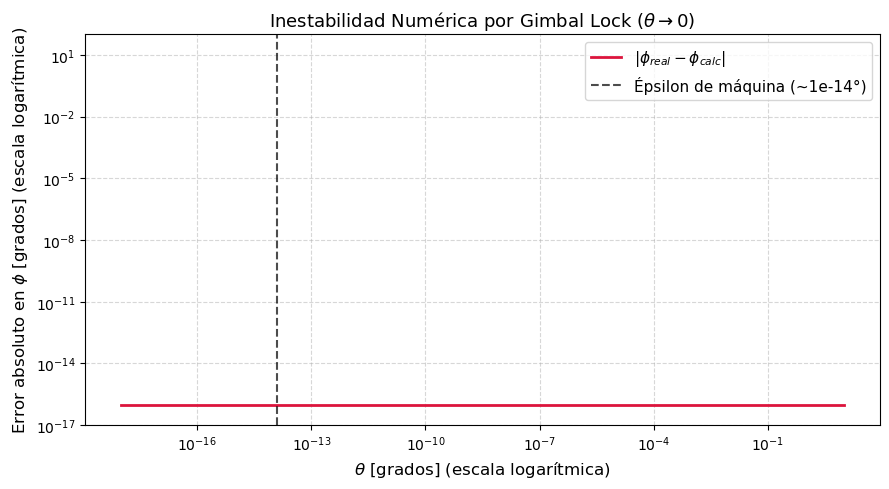

In [3]:
'''
Ejercicio 3: Simulación Caso de Estudio ABB IRB 120  (Validación)
'''
import numpy as np
import matplotlib.pyplot as plt

def rot_z(deg):
    r = np.radians(deg)
    return np.array([[np.cos(r), -np.sin(r), 0],
                     [np.sin(r),  np.cos(r), 0],
                     [0,          0,         1]])

def rot_y(deg):
    r = np.radians(deg)
    return np.array([[ np.cos(r), 0, np.sin(r)],
                     [ 0,         1, 0        ],
                     [-np.sin(r), 0, np.cos(r)]])

def get_R_ZYZ(phi, theta, psi):
# Calcula R_ZYZ = R_z(phi) @ R_y(theta) @ R_z(psi)
    return rot_z(phi) @ rot_y(theta) @ rot_z(psi)

def extraer_angulos_zyz(R):
# Extrae (phi, theta, psi) en grados a partir de una matriz R en SO(3)
    r13, r23, r33 = R[0, 2], R[1, 2], R[2, 2]
    r31, r32      = R[2, 0], R[2, 1]
    
    # 1. Extracción de theta
    sin_theta = np.sqrt(r13**2 + r23**2)
    theta = np.arctan2(sin_theta, r33)
    
    # 2. Extracción de phi y psi
    phi = np.arctan2(r23, r13)
    psi = np.arctan2(r32, -r31)
    
    return np.degrees(phi), np.degrees(theta), np.degrees(psi)


# 1 y 2. Evaluación con theta = 0.0001°

phi_real, psi_real = 45.0, 30.0
theta_1 = 0.0001

R_1 = get_R_ZYZ(phi_real, theta_1, psi_real)
phi_calc_1, theta_calc_1, psi_calc_1 = extraer_angulos_zyz(R_1)

print("--- Apartado 1 y 2: theta = 0.0001° ---")
print("Matriz R_ZYZ:")
print(np.round(R_1, 6))
print(f"\nÁngulos reales:     phi={phi_real}°, theta={theta_1}°, psi={psi_real}°")
print(f"Ángulos calculados: phi={phi_calc_1:.6f}°, theta={theta_calc_1:.6f}°, psi={psi_calc_1:.6f}°")
print(f"Error en phi:       {abs(phi_real - phi_calc_1):.2e}°\n")

# 3. Evaluación con theta = 0.00000000001° (1e-11°)

theta_2 = 1e-11

R_2 = get_R_ZYZ(phi_real, theta_2, psi_real)
phi_calc_2, theta_calc_2, psi_calc_2 = extraer_angulos_zyz(R_2)

print("--- Apartado 3: theta = 1e-11° ---")
print(f"Ángulos reales:     phi={phi_real}°, theta={theta_2}°, psi={psi_real}°")
print(f"Ángulos calculados: phi={phi_calc_2:.6f}°, theta={theta_calc_2:.2e}°, psi={psi_calc_2:.6f}°")
print(f"Error en phi:       {abs(phi_real - phi_calc_2):.4f}°")
print("Observación: Con theta extremadamente pequeño, el truncamiento numérico corrompe la extracción.\n")


# 4. Gráfica Corregida del Error de Extracción |phi_real - phi_calculado| vs theta -> 0

thetas = np.logspace(-18, 1, 500)  
errores_phi = []

# Offset numérico muy pequeño (eps) para evitar log(0)
eps_offset = 1e-16

for th in thetas:
    R_test = get_R_ZYZ(phi_real, th, psi_real)
    phi_c, _, _ = extraer_angulos_zyz(R_test)
    err = abs(phi_real - phi_c)
# Sumamos eps_offset para que no hayan valores exactamente 0 en la escala logarítmica
    errores_phi.append(err + eps_offset)

plt.figure(figsize=(9, 5))
plt.loglog(thetas, errores_phi, color='crimson', linewidth=2, label=r'$|\phi_{real} - \phi_{calc}|$')
plt.axvline(x=np.finfo(float).eps * (180/np.pi), color='black', linestyle='--', alpha=0.7, label='Épsilon de máquina (~1e-14°)')

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xlabel(r'$\theta$ [grados] (escala logarítmica)', fontsize=12)
plt.ylabel(r'Error absoluto en $\phi$ [grados] (escala logarítmica)', fontsize=12)
plt.title(r'Inestabilidad Numérica por Gimbal Lock ($\theta \to 0$)', fontsize=13)
plt.ylim(1e-17, 1e2)  
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()